In [2]:
import pandas as pd
from pathlib import Path

files = Path("/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/silver/motorized_traffic/2025").glob("*.parquet")
#files = Path("/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/silver/pedestrian_bicycle/2025").glob("*.parquet")

df_parquet = pd.concat((pd.read_parquet(f) for f in files), ignore_index=True)


In [3]:
#df = pd.read_csv("/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/bronze/sid_dav_verkehrszaehlung_miv_od2031_2025.csv")
df = df_parquet

df.columns

Index(['id', 'full_text', 'msid', 'msname', 'zsid', 'zsname', 'achse', 'hnr',
       'hoehe', 'ekoord', 'nkoord', 'richtung', 'knummer', 'kname',
       'anz_detektoren', 'd1_id', 'd2_id', 'd3_id', 'd4_id',
       'messung_dat_zeit', 'liefer_dat', 'anz_fahrzeuge',
       'anz_fahrzeuge_status'],
      dtype='object')

In [4]:
df.head()

,id,full_text,msid,msname,zsid,zsname,achse,hnr,hoehe,ekoord,...,kname,anz_detektoren,d1_id,d2_id,d3_id,d4_id,messung_dat_zeit,liefer_dat,anz_fahrzeuge,anz_fahrzeuge_status
0,3624,"'-01':23 '-06':22 '-12':28 '-16':29 '00':25,26...",Z001M001,Unbekannt,Z001,Seestrasse (Strandbad Wollishofen),Seestrasse,451,Unbekannt,2683009.89,...,Badanstalt Wollishofen,1,2,Unbekannt,Unbekannt,Unbekannt,2025-06-01T00:00:00,2025-12-16,223,Gemessen
1,12000,"'-01':23 '-06':22 '-12':28 '-16':29 '00':25,26...",Z001M002,Unbekannt,Z001,Seestrasse (Strandbad Wollishofen),Seestrasse,451,Unbekannt,2683013.18,...,Badanstalt Wollishofen,1,1,Unbekannt,Unbekannt,Unbekannt,2025-06-01T00:00:00,2025-12-16,196,Gemessen
2,20376,'-01':23 '-06':22 '-12':28 '-16':29 '/paradies...,Z002M001,Unbekannt,Z002,Albisstrasse (Widmerstrasse),Albisstrasse,152,Unbekannt,2682480.51,...,Albis-/Paradies-/Widmerstr (Schulweg),1,13,Unbekannt,Unbekannt,Unbekannt,2025-06-01T00:00:00,2025-12-16,131,Gemessen
3,28752,'-01':23 '-06':22 '-12':28 '-16':29 '/paradies...,Z002M002,Unbekannt,Z002,Albisstrasse (Widmerstrasse),Albisstrasse,152,Unbekannt,2682484.91,...,Albis-/Paradies-/Widmerstr (Schulweg),1,14,Unbekannt,Unbekannt,Unbekannt,2025-06-01T00:00:00,2025-12-16,86,Gemessen
4,37128,'-01':22 '-06':21 '-12':27 '-16':28 '/leimbach...,Z003M001,Unbekannt,Z003,Sood-/Leimbachstrasse,Soodstrasse,Unbekannt,Leimbachstrasse,2681573.79,...,Leimbach-/Soodstr,1,16,Unbekannt,Unbekannt,Unbekannt,2025-06-01T00:00:00,2025-12-16,96,Gemessen


In [3]:
cols = [
        "MSID", "MSName", "ZSID", "ZSName",
        "Achse", "HNr", "Hoehe",
        "EKoord", "NKoord", "Richtung",
        "MessungDatZeit", "AnzFahrzeuge", "AnzFahrzeugeStatus",
    ]



    # Restrict to relevant columns if present
df = df[[c for c in df.columns if c in cols]].copy()
    

    # Types
df["AnzFahrzeuge"] = pd.to_numeric(df["AnzFahrzeuge"], errors="coerce")
df["MessungDatZeit"] = pd.to_datetime(df["MessungDatZeit"], errors="coerce")
df["EKoord"] = pd.to_numeric(df["EKoord"], errors="coerce")
df["NKoord"] = pd.to_numeric(df["NKoord"], errors="coerce")

KeyError: 'AnzFahrzeuge'

In [32]:
df.EKoord.value_counts()

EKoord
2681286.900    16752
2685813.350    16752
2678135.590     8376
2679771.840     8376
2678632.000     8376
               ...  
2679597.690     3529
2679579.558      288
2679559.958      288
2679636.536      288
2679623.683      288
Name: count, Length: 214, dtype: int64

In [26]:

from pyproj import Transformer
# Drop rows without valid timestamp or coordinates
df = df.dropna(subset=["MessungDatZeit", "EKoord", "NKoord"]).copy()

    # Hour-of-day (0–23)
df["hour"] = df["MessungDatZeit"].dt.hour.astype("Int64")

    # --------------------------------------------------------------
    # 2. LV95 -> WGS84 & build stations GeoDataFrame
    # --------------------------------------------------------------
transformer = Transformer.from_crs("EPSG:2056", "EPSG:4326", always_xy=True)
lon, lat = transformer.transform(df["EKoord"].values, df["NKoord"].values)
df["lon"] = lon
df["lat"] = lat

In [27]:
df.EKoord.value_counts()

EKoord
2683009.89    8088
2683013.18    8088
2682480.51    8088
2682484.91    7736
Name: count, dtype: int64

In [28]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326",
    )


In [29]:
gdf.to_file("/Users/fadricampell/Desktop/points.gpkg", layer="points", driver="GPKG")


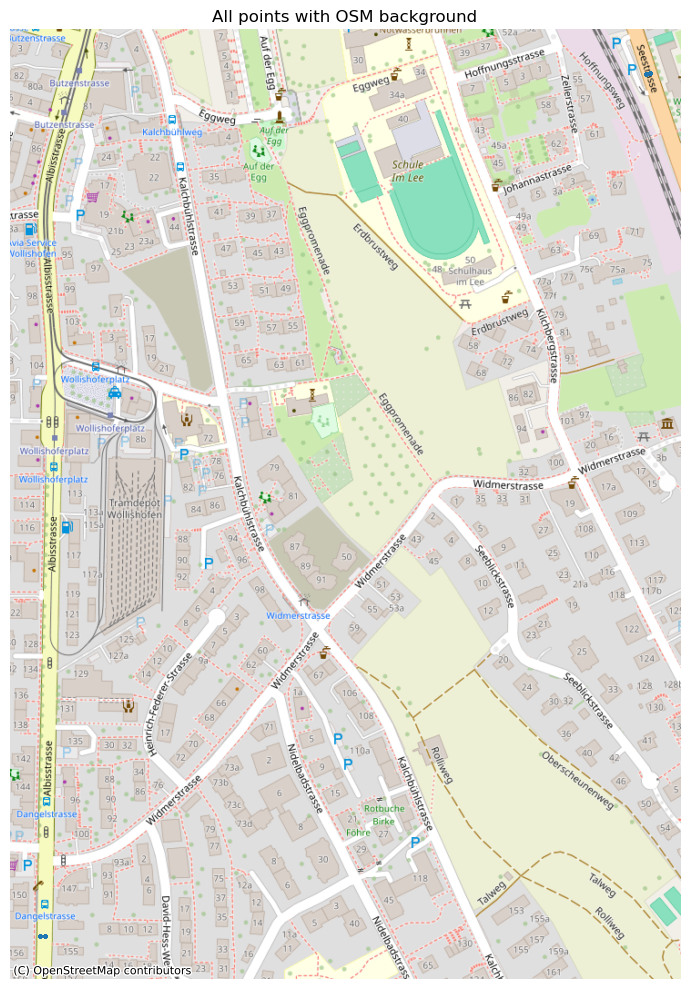

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

# your GeoDataFrame (already EPSG:4326)
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326",
)

# contextily needs Web Mercator
gdf_3857 = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_3857.plot(
    ax=ax,
    markersize=3,
    alpha=0.6
)

cx.add_basemap(
    ax,
    source=cx.providers.OpenStreetMap.Mapnik
)

ax.set_axis_off()
ax.set_title("All points with OSM background")

plt.tight_layout()
plt.show()


In [6]:
gdf.columns

Index(['MSID', 'MSName', 'ZSID', 'ZSName', 'Achse', 'HNr', 'Hoehe', 'EKoord',
       'NKoord', 'Richtung', 'MessungDatZeit', 'AnzFahrzeuge',
       'AnzFahrzeugeStatus', 'hour', 'lon', 'lat', 'geometry'],
      dtype='object')

<Axes: >

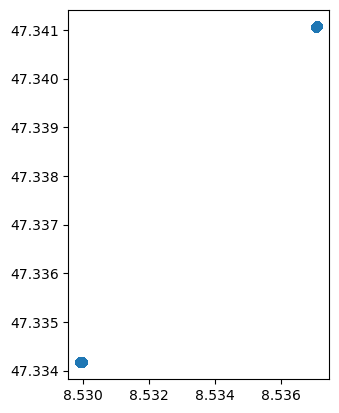

In [8]:
gdf.plot()